# Cohort Analysis — Customer Retention

## Цель анализа

Цель этапа — оценить удержание клиентов после первой покупки и определить, насколько пользователи возвращаются для повторных заказов.

В рамках анализа:
- формируются клиентские когорты по месяцу первой покупки;
- рассчитывается retention по месяцам;
- оценивается динамика повторного взаимодействия клиентов.

## 1. Подготовка данных

Для когортного анализа используются таблицы:

- `orders` — информация о заказах;
- `customers` — информация о клиентах.

Клиент идентифицируется через `customer_unique_id`, так как он соответствует одному пользователю независимо от количества заказов.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
DATA_PATH = "../data/"

customers = pd.read_csv(
    DATA_PATH + "olist_customers_dataset.csv"
)

orders = pd.read_csv(
    DATA_PATH + "olist_orders_dataset.csv"
)

items = pd.read_csv(
    DATA_PATH + "olist_order_items_dataset.csv"
)

payments = pd.read_csv(
    DATA_PATH + "olist_order_payments_dataset.csv"
)

reviews = pd.read_csv(
    DATA_PATH + "olist_order_reviews_dataset.csv"
)

products = pd.read_csv(
    DATA_PATH + "olist_products_dataset.csv"
)

sellers = pd.read_csv(
    DATA_PATH + "olist_sellers_dataset.csv"
)

geo = pd.read_csv(
    DATA_PATH + "olist_geolocation_dataset.csv"
)

categories = pd.read_csv(
    DATA_PATH + "product_category_name_translation.csv"
)

In [ ]:
datasets = {
    "customers": customers,
    "orders": orders,
    "items": items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geo": geo,
    "categories": categories
}

orders = orders[
    orders['order_status'] == 'delivered'
]

cohort = orders.merge(
    customers,
    on='customer_id'
)

cohort['order_purchase_timestamp'] = pd.to_datetime(
    cohort['order_purchase_timestamp']
)

Для анализа удержания учитываются только успешно завершённые заказы.
Отменённые и недоставленные заказы исключаются, так как они не отражают реальное взаимодействие клиента с платформой.

## 2. Определение первой покупки клиента

Для каждого клиента определяется месяц первой покупки.

Этот месяц используется для формирования когорты:
- пользователи, совершившие первую покупку в одном месяце, относятся к одной группе.

In [15]:
cohort['cohort_month'] = (
    cohort
    .groupby('customer_unique_id')
    ['order_purchase_timestamp']
    .transform('min')
    .dt.to_period('M')
)

## 3. Расчёт месяца активности клиента

Для каждого заказа определяется месяц покупки.

Затем рассчитывается номер месяца относительно первой покупки:

- 0 — месяц первой покупки;
- 1 — следующий месяц;
- 2 — второй месяц после первой покупки.

In [16]:
cohort['order_month'] = (
    cohort['order_purchase_timestamp']
    .dt.to_period('M')
)

In [17]:
cohort['cohort_index'] = (
    (cohort['order_month'].dt.year -
     cohort['cohort_month'].dt.year) * 12
    +
    (cohort['order_month'].dt.month -
     cohort['cohort_month'].dt.month)
)

## 4. Формирование когортной таблицы

На данном этапе рассчитывается количество уникальных клиентов в каждой когорте в каждый месяц активности.

In [18]:
cohort_data = (
    cohort
    .groupby(
        ['cohort_month', 'cohort_index']
    )
    ['customer_unique_id']
    .nunique()
    .reset_index()
)

In [19]:
cohort_table = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_unique_id'
)

## 5. Расчёт Customer Retention

Retention показывает долю клиентов, которые продолжают совершать покупки после первой покупки.

Формула:

Retention = количество активных клиентов в месяце N / количество клиентов в первый месяц когорты

In [ ]:
retention = cohort_table.divide(
    cohort_table[0],
    axis=0
)

retention = retention.iloc[:, :6]

print(retention)

cohort_index   0         1         2         3         4         5         6   \
cohort_month                                                                    
2016-09       1.0       NaN       NaN       NaN       NaN       NaN       NaN   
2016-10       1.0       NaN       NaN       NaN       NaN       NaN  0.003115   
2016-12       1.0  1.000000       NaN       NaN       NaN       NaN       NaN   
2017-01       1.0  0.003927  0.002618  0.001309  0.003927  0.001309  0.005236   
2017-02       1.0  0.002283  0.002854  0.001142  0.003995  0.001142  0.002283   
2017-03       1.0  0.004932  0.003794  0.003794  0.003414  0.001517  0.001517   
2017-04       1.0  0.005952  0.002126  0.001701  0.003401  0.002551  0.003401   
2017-05       1.0  0.005006  0.005006  0.003893  0.003059  0.003337  0.004171   
2017-06       1.0  0.004779  0.003504  0.004141  0.002549  0.003823  0.003823   
2017-07       1.0  0.005136  0.003595  0.002568  0.002825  0.002054  0.003082   
2017-08       1.0  0.006931 

Для корректного сравнения когорт анализ ограничен первыми 6 месяцами после первой покупки.
Последние когорты исключаются из долгосрочного сравнения из-за недостаточного периода наблюдения.

## 6. Визуализация когорт

Heatmap позволяет оценить динамику удержания клиентов:

- строки — месяц первой покупки клиента;
- столбцы — месяц после первой покупки;
- значения — количество активных клиентов.

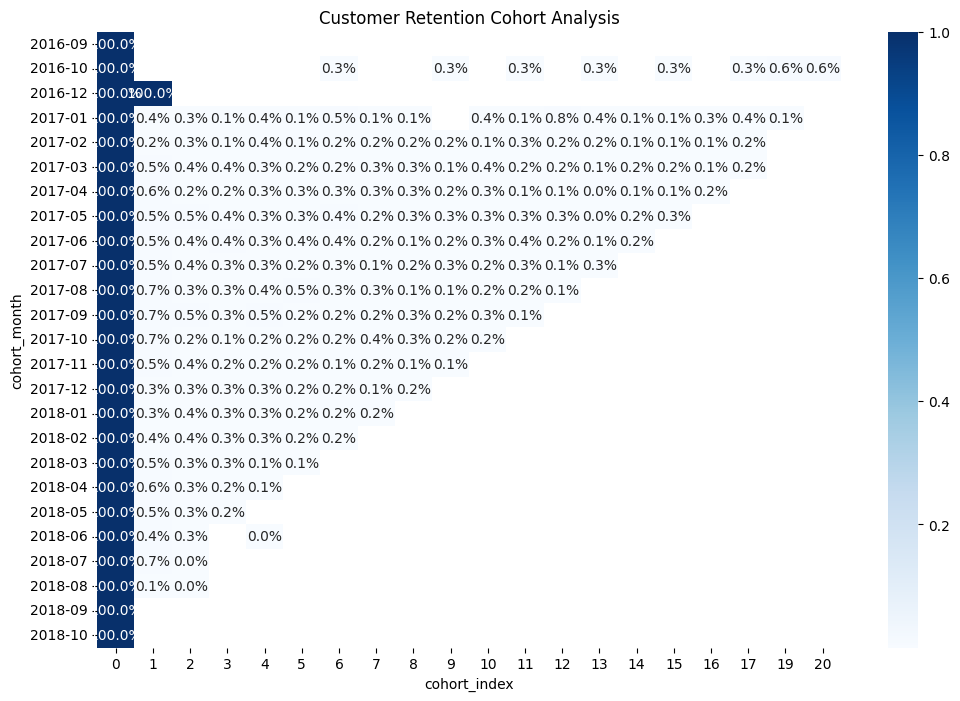

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    cohort_table,
    annot=True,
    fmt='.0f'
)

plt.title(
    'Customers Count by Cohort'
)


plt.show()

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt='.1%',
    cmap='Blues'
)

plt.title(
    'Customer Retention Rate by Cohort'
)

plt.show()

In [ ]:
average_retention = (
    retention
    .mean()
    .reset_index()
)

average_retention.columns = [
    'month',
    'retention'
]


average_retention

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(
    average_retention['month'],
    average_retention['retention']
)

plt.title(
    'Average Customer Retention'
)

plt.xlabel(
    'Month after first purchase'
)

plt.ylabel(
    'Retention'
)

plt.show()

## 7. Business Insights

Основные выводы:

1. Retention значительно снижается после первой покупки.
Большинство клиентов не возвращаются в следующие месяцы после первого заказа.

2. Проблема низкого удержания наблюдается во всех когортах.
Новые пользователи не демонстрируют улучшения retention, поэтому проблема является системной.

3. Результаты когортного анализа подтверждают выводы Business Overview:
низкий Repeat Purchase Rate связан с отсутствием повторных заказов.

4. Основной потенциал роста платформы связан не только с привлечением новых клиентов, но и с увеличением LTV существующих пользователей.